# Image Classification Project: Glove Detection

## Project Overview
This project demonstrates the development of a Convolutional Neural Network (CNN) for the task of glove detection in images. The goal is to classify whether an image contains a person wearing gloves or not. This document outlines the key steps involved, including data loading, preprocessing, model architecture definition, training, evaluation, and prediction with visualization.

## Table of Contents
1.  **Environment Setup and Library Imports**
2.  **Data Loading and Preprocessing**
3.  **Model Architecture Definition**
4.  **Model Training**
5.  **Model Evaluation**
6.  **Model Saving**
7.  **Single Image Prediction and Visualization**

## 1. Environment Setup and Library Imports

This section handles the setup of our Python environment by importing all necessary libraries. This includes TensorFlow for building and training the neural network, Keras for its high-level API, NumPy for numerical operations, OpenCV (cv2) for image processing, and Matplotlib for visualization.

In [17]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np
import cv2
import matplotlib.pyplot as plt

## 2. Data Loading and Preprocessing

In this phase, we prepare our image dataset for training and testing. We define the directories for our training and testing images and use Keras's `ImageDataGenerator` to perform data augmentation (though only rescaling is applied here) and efficient batch loading. The images are resized to 224x224 pixels and scaled to a range of [0, 1].

In [18]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "/content/drive/MyDrive/dataset/train"
test_dir = "/content/drive/MyDrive/dataset/test"

train_gen = ImageDataGenerator(rescale=1./255)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 890 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


# 2. Model Definition
This cell defines the Convolutional Neural Network (CNN) architecture using Keras Sequential API. It includes convolutional layers (`Conv2D`), max pooling layers (`MaxPooling2D`), a flattening layer (`Flatten`), and dense layers (`Dense`) for classification. The model is then compiled with the Adam optimizer, binary cross-entropy loss, and accuracy as a metric. A summary of the model's architecture is also displayed.

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,521 (91.20 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

# 3. Model Training
This cell initiates the training process for the defined CNN model. It uses the `fit` method, providing the training data (`train_data`) and validation data (`test_data`). The model is trained for 10 epochs, and the training progress (loss and accuracy for both training and validation sets) is displayed during each epoch.

In [20]:
model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 309ms/step - accuracy: 0.7191 - loss: 1.3268 - val_accuracy: 0.7814 - val_loss: 0.4372
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 209ms/step - accuracy: 0.8719 - loss: 0.3400 - val_accuracy: 0.8047 - val_loss: 0.3830
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 272ms/step - accuracy: 0.9056 - loss: 0.2925 - val_accuracy: 0.8279 - val_loss: 0.3573
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 211ms/step - accuracy: 0.8933 - loss: 0.2484 - val_accuracy: 0.8279 - val_loss: 0.3707
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 232ms/step - accuracy: 0.9371 - loss: 0.1861 - val_accuracy: 0.8233 - val_loss: 0.4781
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 220ms/step - accuracy: 0.9270 - loss: 0.1786 - val_accuracy: 0.8047 - val_loss: 0.4547
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 221ms/step - accuracy: 0.9640 - loss: 0.1115 - val_accuracy: 0.7628 - val_loss: 0.6481
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 230ms/step - accuracy: 0.9685 - loss: 0.0901 - val_accuracy: 0

## 5. Model Evaluation

After training, it's crucial to evaluate the model's performance on unseen data to assess its generalization capabilities. This section evaluates the trained model on the `test_data` to report the final loss and accuracy.

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - accuracy: 0.8000 - loss: 0.8060
Test Loss: 0.8060
Test Accuracy: 0.8000


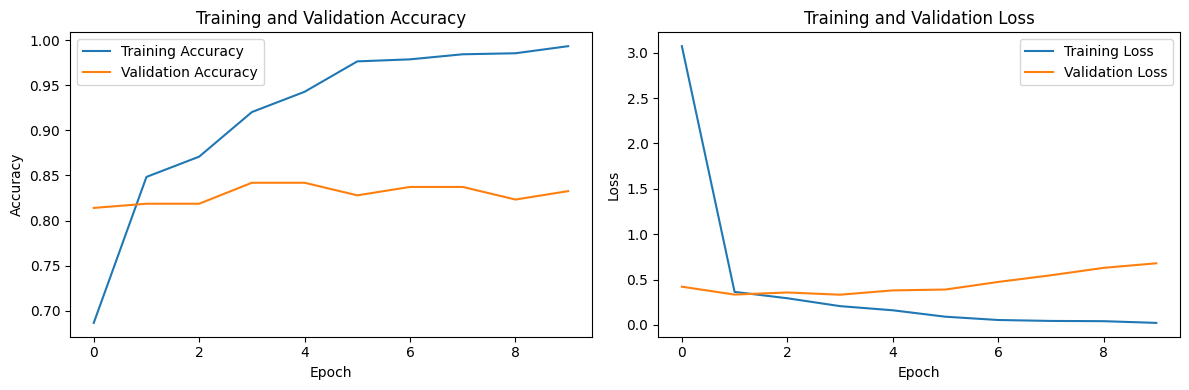

In [21]:
loss, accuracy = model.evaluate(test_data)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Optional: Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 4. Model Saving
This cell saves the trained model to a file named 'gloves_model.h5'. Saving the model allows it to be reused later without needing to retrain it, which is useful for deployment or further analysis.

In [22]:
model.save("gloves_model.h5")

# 5. Model Prediction and Visualization
This cell loads the previously saved model. It then loads a specific test image (`/content/test6.jpeg`), preprocesses it (resizing and scaling), and uses the loaded model to make a prediction. Based on the prediction probability, it determines if gloves are detected or not. Finally, it displays the input image with the prediction result as its title using `matplotlib`.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
Prediction: 0.1275 - Gloves detected


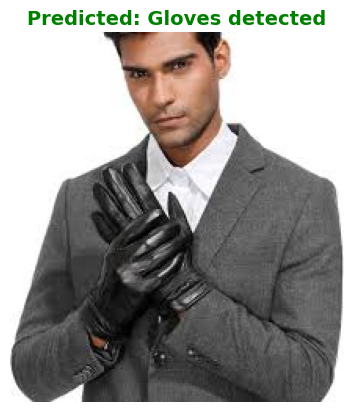

In [23]:
# Load the saved model
loaded_model = load_model("gloves_model.h5")

# Define the path to the image for prediction
image_filename = "/content/test6.jpeg"

# Load and preprocess the image
img_raw = cv2.imread(image_filename)
if img_raw is None:
    print(f"Error: Unable to load image from {image_filename}")
else:
    img_resized = cv2.resize(img_raw, (224, 224))
    # Normalize pixel values
    img_normalized = img_resized / 255.0
    # Expand dimensions to match model input shape (batch_size, height, width, channels)
    img_batch = np.expand_dims(img_normalized, axis=0)

    # Make a prediction
    prediction = loaded_model.predict(img_batch)

    # Interpret the prediction
    if prediction[0] < 0.5:
        result = "Gloves detected"
        color = 'green'
    else:
        result = "Person NOT wearing gloves"
        color = 'red'

    print(f"Prediction: {prediction[0][0]:.4f} - {result}")

    # Display the image with the prediction title
    plt.imshow(cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)) # Display original image for better view
    plt.title(f"Predicted: {result}", color=color, fontsize=14, fontweight='bold')
    plt.axis('off') # Hide axes ticks and labels
    plt.show()